In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display
import librosa

# Helpers

In [2]:
def print_params(model):
    for name, param in model.named_parameters():
        print(f"{name}: shape={param.shape}")
        print(param.data)
        print()

# Training Data

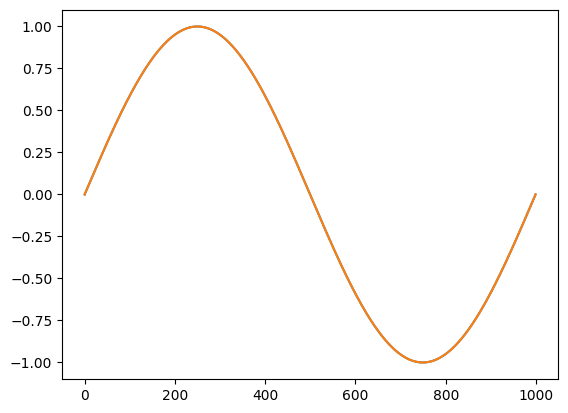

In [3]:
import matplotlib.pyplot as plt
from math import sin


x = torch.randn(50000, 2) * 0.8  # random stereo samples
x[:10]

xs = np.linspace(0, 1, 1000)
f = 1.0
s = np.vstack((np.sin(f * np.pi * 2.0 * xs), np.sin(f * np.pi * 2.0 * xs)))

# Convert to tensor with shape (N, 2) for tube_sim
s = torch.from_numpy(s.T).float()

plt.plot(s.numpy())

# Tube Sim

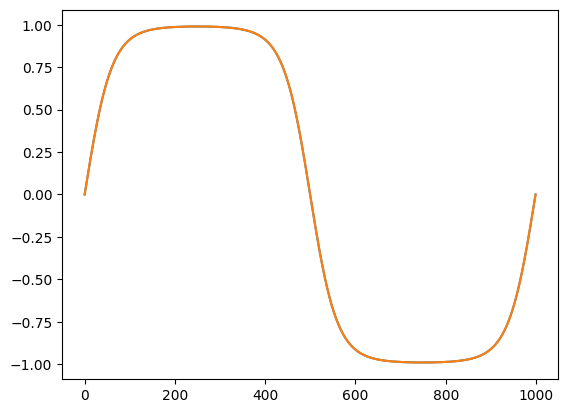

In [4]:
def tube_sim(x):
    L, R = x[:, 0], x[:, 1]
    crosstalk = 0.05
    L_mixed = L + crosstalk * R
    R_mixed = R + crosstalk * L
    L_out = torch.tanh(2.5 * L_mixed)
    R_out = torch.tanh(2.5 * R_mixed)
    return torch.stack([L_out, R_out], dim=1)

y = tube_sim(s)

plt.plot(y)

In [ ]:
model = nn.Sequential(
    nn.Linear(2, 16),
    nn.ReLU(),
    nn.Linear(16, 16),
    nn.ReLU(),
    nn.Linear(16, 2),
)

num_epochs = 1000
learning_rate = 0.001
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
loss_fn = nn.MSELoss()

for epoch in range(num_epochs):
    pred = model(s)
    loss = loss_fn(pred, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: loss={loss.item():.6f}")

# print_params(model)


Epoch 0: loss=0.838539
Epoch 100: loss=0.423174
Epoch 200: loss=0.010387
Epoch 300: loss=0.002459
Epoch 400: loss=0.002002
Epoch 500: loss=0.001622
Epoch 600: loss=0.001309
Epoch 700: loss=0.001064
Epoch 800: loss=0.000876
Epoch 900: loss=0.000733


In [11]:
for name, param in model.named_parameters():
    print(param.size())
        

torch.Size([16, 2])
torch.Size([16])
torch.Size([16, 16])
torch.Size([16])
torch.Size([2, 16])
torch.Size([2])


In [12]:
import torch.nn as nn
import json

def export_model(model,filepath, name="model", description="", sample_rate=48000, num_epochs=0, final_loss=0.0,
                 loss_function="mse", optimizer="adam", learning_rate=0.001):
    linear_layers = [l for l in model.children() if isinstance(l, (nn.Linear, nn.Conv1d, nn.GRU))]
    
    num_parameters = sum(p.numel() for p in model.parameters())
    
    data = {
        "name": name,
        "sample_rate": sample_rate,
        "num_parameters": num_parameters,
        "in_shape": linear_layers[0].in_features,
        "out_size": linear_layers[-1].out_features,
        "weight_layout": "in_out",
        "training": {
            "epochs": num_epochs,
            "final_loss": float(final_loss),
            "loss_function": loss_function,
            "optimizer": optimizer,
            "learning_rate": learning_rate,
        },
        "layers": []
    }

    layers = list(model.children())
    
    # Old fashioned indexing to get to activation functions easier...
    i = 0
    while i < len(layers):
        layer = layers[i]
        
        act = ""
        if i + 1 < len(layers):
            next_layer = layers[i + 1]
            act_map = {nn.ReLU: "relu", nn.Tanh: "tanh"}
            for cls, name_str in act_map.items():
                if isinstance(next_layer, cls):
                    act = name_str
                    i += 1
                    break
        
        if isinstance(layer, nn.Linear):
            data["layers"].append({
                "type": "dense",
                "in_size": layer.in_features,
                "out_size": layer.out_features,
                "activation": act,
                "weights": layer.weight.data.t().tolist(),
                "bias": layer.bias.data.tolist()
            })
        
        elif isinstance(layer, nn.Conv1d):
            data["layers"].append({
                "type": "conv1d",
                "in_channels": layer.in_channels,
                "out_channels": layer.out_channels,
                "kernel_size": layer.kernel_size[0],
                "dilation": layer.dilation[0],
                "activation": act,
                "weights": layer.weight.data.tolist(),
                "bias": layer.bias.data.tolist() if layer.bias is not None else []
            })
        
        elif isinstance(layer, nn.GRU):
            data["layers"].append({
                "type": "gru",
                "in_size": layer.input_size,
                "hidden_size": layer.hidden_size,
                "weights_ih": layer.weight_ih_l0.data.tolist(),
                "weights_hh": layer.weight_hh_l0.data.tolist(),
                "bias_ih": layer.bias_ih_l0.data.tolist(),
                "bias_hh": layer.bias_hh_l0.data.tolist()
            })
        
        i += 1


    try:
        with open(filepath, 'w') as f:
            json.dump(data, f, indent=4)
        
        print(f"Exported {len(data['layers'])} layers ({num_parameters} parameters) to {filepath}")
    except():
        print("Failed to export the model")
    


export_model(model, "model.json", 
    name="tube_saturator_v1",
    description="Stereo tube summing saturation with crosstalk",
    num_epochs=num_epochs,
    final_loss=loss.item(),
    learning_rate=learning_rate,
)

Exported 3 layers (354 parameters) to model.json
